# CNN Using PyTorch

The venomous and non-venomous classification problem can play a vital role in many rural areas. This notebook is a tutorial of how you can use this dataset to make a real-life model. This notebook uses Pytorch library to make a CNN. You can try keras and tensorflow too to make a CNN model. Here I am making a simple NN model as complex models won't work in this situation according to me.

In [1]:
import os
import pandas as pd
import numpy as np
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
from torchvision.datasets import CIFAR10
from torchvision.transforms import ToTensor
from torchvision.utils import make_grid
from torch.utils.data.dataloader import DataLoader
from torchvision import datasets, transforms
from torch.utils.data import random_split, Dataset
# from translate.py import translate
import torchvision.models as models

import random
%matplotlib inline

In [2]:
class MyDataSet(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
        
    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y
    
    def __len__(self):
        return len(self.subset)

In [3]:
data_dir = '../input/snake-dataset-india/Snake Images/train'
classes = (os.listdir(data_dir))


dataset = datasets.ImageFolder(data_dir, transform = transforms.Compose([
    transforms.Resize((288,288)), 
    transforms.ToTensor(),
    ]))

img, label = dataset[10]
print(img.shape, label)
img
print(dataset.classes)

torch.Size([3, 288, 288]) 0
['Non Venomous', 'Venomous']


In [4]:
test_dir = '../input/snake-dataset-india/Snake Images/test'

test = datasets.ImageFolder(test_dir, transform = transforms.Compose([
    transforms.Resize((288,288)), 
    transforms.ToTensor(),
    ]))

Label: Venomous (1)


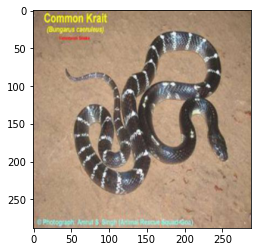

In [5]:
def show(img, label):
    print('Label:', dataset.classes[label], '(' + str(label)+')')
    plt.imshow(img.permute(1,2,0))
show(*dataset[random.randint(1,len(dataset))])

In [6]:
random_seed = 45
torch.manual_seed(random_seed)
val_size = 100
test_size = len(test)
train_size = len(dataset) - val_size
train_size + val_size + test_size

2044

In [7]:
train_ds, val_ds = random_split(dataset, [train_size, val_size])
len(train_ds), len(val_ds)

(1675, 100)

In [8]:
stats = ((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
train_set = MyDataSet(train_ds, transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(*stats, inplace=True),

    ]))

val_set = MyDataSet(val_ds, transform = transforms.Normalize(*stats, inplace=True))


test_set = MyDataSet(test, transform = transforms.Normalize(*stats, inplace=True))


In [9]:
len(test_set), len(train_set)
train_set[0][0].shape

torch.Size([3, 288, 288])

In [10]:
from torchvision.utils import make_grid

def show_batch(dl):
    for images, labels in dl:
        fig, ax = plt.subplots(figsize=(24,6))
        ax.set_xticks([]); ax.set_yticks([])
        ax.imshow(make_grid(images, nrow=16).permute(1,2,0))
        break

In [11]:
batch_size = 8
train_loader = DataLoader(train_set, batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_set, 16, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_set, 16, num_workers=2, pin_memory=True)

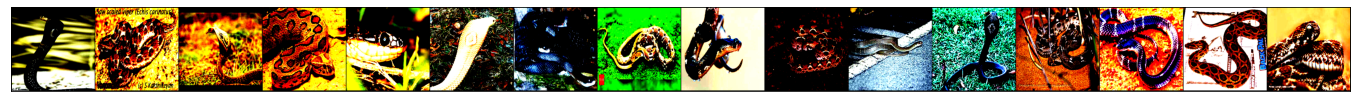

In [12]:
show_batch(val_loader)

In [13]:
def accuracy(outputs, labels):
    _, preds = torch.max(outputs, dim=1)
    valid_preds = torch.sum(preds == labels).item()
    all_preds = len(preds)
    return torch.tensor(valid_preds/all_preds)

In [14]:
class ModelBase(nn.Module):
    def training_step(self, batch):
        images, labels = batch 
        out = self(images)                  # Generate predictions
        loss = F.cross_entropy(out, labels) # Calculate loss
        return loss
    
    def validation_step(self, batch):
        images, labels = batch 
        out = self(images)                    # Generate predictions
        loss = F.cross_entropy(out, labels)   # Calculate loss
        acc = accuracy(out, labels)           # Calculate accuracy
        return {'val_loss': loss.detach(), 'val_acc': acc}
        
    def validation_epoch_end(self, outputs):
        batch_losses = [x['val_loss'] for x in outputs]
        epoch_loss = torch.stack(batch_losses).mean()   # Combine losses
        batch_accs = [x['val_acc'] for x in outputs]
        epoch_acc = torch.stack(batch_accs).mean()      # Combine accuracies
        return {'val_loss': epoch_loss.item(), 'val_acc': epoch_acc.item()}
    
    def epoch_end(self, epoch, result):
        print("Epoch [{}], last_lr: {:.5f}, train_loss: {:.4f}, val_loss: {:.4f}, val_acc: {:.4f}".format(
            epoch, result['lrs'][-1], result['train_loss'], result['val_loss'], result['val_acc']))
    

In [15]:
@torch.no_grad()
def evaluate(model, val_loader):
    model.eval()
    outputs = [model.validation_step(batch) for batch in val_loader]
    return model.validation_epoch_end(outputs)

def get_lr(optimizer):
    for param_group in optimizer.param_groups:
        return param_group['lr']

    
def fit_one_cycle(epochs, max_lr, model, train_loader, val_loader, weight_decay=0, grad_clip=None, opt_func=torch.optim.SGD):
    torch.cuda.empty_cache()
    history = []
    
    optimizer = opt_func(model.parameters(), max_lr, weight_decay=weight_decay)
    
    sched = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr, epochs=epochs, steps_per_epoch=len(train_loader))
    
    
    for epoch in range(epochs):
        # Training Phase 
        model.train()
        train_losses = []
        lrs = []
        for batch in train_loader:
            loss = model.training_step(batch)
            train_losses.append(loss)
            loss.backward()
            if grad_clip:
                nn.utils.clip_grad_value_(model.parameters(), grad_clip)

            optimizer.step()
            optimizer.zero_grad()
            lrs.append(get_lr(optimizer))
            sched.step()
            
        # Validation phase
        result = evaluate(model, val_loader)
        result['train_loss'] = torch.stack(train_losses).mean().item()
        result['lrs'] = lrs
        model.epoch_end(epoch, result)
        history.append(result)
    return history

In [16]:
def get_default_device():
    """Pick GPU if available, else CPU"""
    if torch.cuda.is_available():
        return torch.device('cuda')
    else:
        return torch.device('cpu')

In [17]:
device = get_default_device()
device

device(type='cuda')

In [18]:
def plot_losses(history):
    train_losses = [x.get('train_loss') for x in history]
    val_losses = [x['val_loss'] for x in history]
    plt.plot(train_losses, '-bx')
    plt.plot(val_losses, '-rx')
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.legend(['Training', 'Validation'])
    plt.title('Loss vs. No. of epochs');

In [19]:
def plot_accuracies(history):
    accuracies = [x['val_acc'] for x in history]
    plt.plot(accuracies, '-x')
    plt.xlabel('epoch')
    plt.ylabel('accuracy')
    plt.title('Accuracy vs. No. of epochs');

In [20]:
input_size = 3
output_size = 2

In [21]:
def conv_block(in_channels, out_channels, pool=False):
    layers = [nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1), 
              nn.BatchNorm2d(out_channels), 
              nn.ReLU(inplace=True)]
    if pool: layers.append(nn.MaxPool2d(5))
    return nn.Sequential(*layers)

class Model1(ModelBase):
    def __init__(self, in_channels, num_classes):
        super().__init__()
        
        self.conv1 = conv_block(in_channels, 64)
        self.conv2 = conv_block(64, 128, pool=True)
        self.res1 = nn.Sequential(conv_block(128, 128), conv_block(128, 128))
        
        self.conv3 = conv_block(128, 256, pool=True)
        self.conv4 = conv_block(256, 512, pool=True)
        self.res2 = nn.Sequential(conv_block(512,512), conv_block(512, 512))
        
        self.classifier = nn.Sequential(nn.MaxPool2d(2), 
                                        nn.Flatten(), 
                                        nn.Linear(512, num_classes))
        
    def forward(self, xb):
        out = self.conv1(xb)
        out = self.conv2(out)
        out = self.res1(out) + out
        out = self.conv3(out)
        out = self.conv4(out)
        out = self.res2(out) + out
        out = self.classifier(out)
        return out

In [22]:
class Model2(ModelBase):
    def __init__(self):
        super().__init__()
        # Use a pretrained model
        self.network = models.resnet34(pretrained=True)
        # Replace last layer
        num_ftrs = self.network.fc.in_features
        self.network.fc = nn.Linear(num_ftrs, 10)
    
    def forward(self, xb):
        return torch.sigmoid(self.network(xb))

In [23]:
model = Model1(3,2)
model

Model1(
  (conv1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (conv2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=5, stride=5, padding=0, dilation=1, ceil_mode=False)
  )
  (res1): Sequential(
    (0): Sequential(
      (0): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (1): Sequential(
      (0): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=Tru

In [24]:
for images, labels in train_loader:
    print('images.shape: ', images.shape)
    out = model(images)
    print('out.shape: ', out.shape)
    print("out[0]: ", out[0])
    break

images.shape:  torch.Size([8, 3, 288, 288])
out.shape:  torch.Size([8, 2])
out[0]:  tensor([-1.5973, -0.2793], grad_fn=<SelectBackward>)


In [25]:
def get_default_device():
    """Pick GPU if available, else CPU"""
    if torch.cuda.is_available():
        return torch.device('cuda')
    else:
        return torch.device('cpu')
    
def to_device(data, device):
    """Move tensor(s) to chosen device"""
    if isinstance(data, (list,tuple)):
        return [to_device(x, device) for x in data]
    return data.to(device, non_blocking=True)

class DeviceDataLoader():
    """Wrap a dataloader to move data to a device"""
    def __init__(self, dl, device):
        self.dl = dl
        self.device = device
        
    def __iter__(self):
        """Yield a batch of data after moving it to device"""
        for b in self.dl: 
            yield to_device(b, self.device)

    def __len__(self):
        """Number of batches"""
        return len(self.dl)

In [26]:
train_loader = DeviceDataLoader(train_loader, device)
val_loader = DeviceDataLoader(val_loader, device)
test_loader = DeviceDataLoader(test_loader, device)
device = get_default_device()
device
to_device(model, device)

Model1(
  (conv1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (conv2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=5, stride=5, padding=0, dilation=1, ceil_mode=False)
  )
  (res1): Sequential(
    (0): Sequential(
      (0): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (1): Sequential(
      (0): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=Tru

In [33]:
epochs = 20
max_lr = 0.005
grad_clip = 0.1
weight_decay = 1e-5
opt_func = torch.optim.Adam

In [34]:
evaluate(model, val_loader)

{'val_loss': 0.6362766623497009, 'val_acc': 0.625}

In [35]:
evaluate(model, test_loader)

{'val_loss': 0.6502708196640015, 'val_acc': 0.601244330406189}

In [36]:
%%time
history = []
history += fit_one_cycle(epochs, max_lr, model, train_loader, val_loader, 
                             grad_clip=grad_clip, 
                             weight_decay=weight_decay, 
                             opt_func=opt_func)

Epoch [0], last_lr: 0.00052, train_loss: 0.5925, val_loss: 0.6144, val_acc: 0.6071
Epoch [1], last_lr: 0.00140, train_loss: 0.6291, val_loss: 0.5809, val_acc: 0.6607
Epoch [2], last_lr: 0.00260, train_loss: 0.6553, val_loss: 0.9972, val_acc: 0.5714
Epoch [3], last_lr: 0.00380, train_loss: 0.7042, val_loss: 0.5272, val_acc: 0.7500
Epoch [4], last_lr: 0.00468, train_loss: 0.6888, val_loss: 0.6215, val_acc: 0.6071
Epoch [5], last_lr: 0.00500, train_loss: 0.6767, val_loss: 0.5584, val_acc: 0.7143
Epoch [6], last_lr: 0.00494, train_loss: 0.6581, val_loss: 0.6349, val_acc: 0.6964
Epoch [7], last_lr: 0.00475, train_loss: 0.6441, val_loss: 0.8745, val_acc: 0.5804
Epoch [8], last_lr: 0.00445, train_loss: 0.6392, val_loss: 0.6191, val_acc: 0.6696
Epoch [9], last_lr: 0.00406, train_loss: 0.6218, val_loss: 1.1236, val_acc: 0.3929
Epoch [10], last_lr: 0.00358, train_loss: 0.6158, val_loss: 0.6023, val_acc: 0.6696
Epoch [11], last_lr: 0.00306, train_loss: 0.5875, val_loss: 0.5921, val_acc: 0.6696
Ep

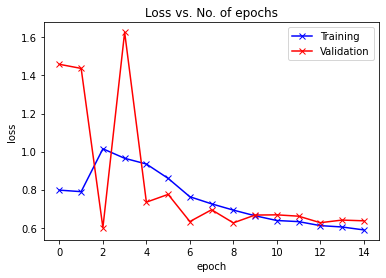

In [31]:
plot_losses(history)

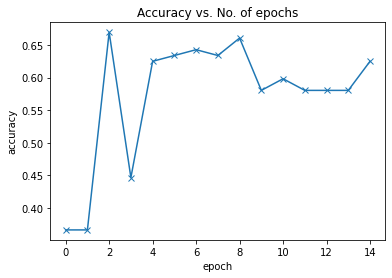

In [32]:
plot_accuracies(history)

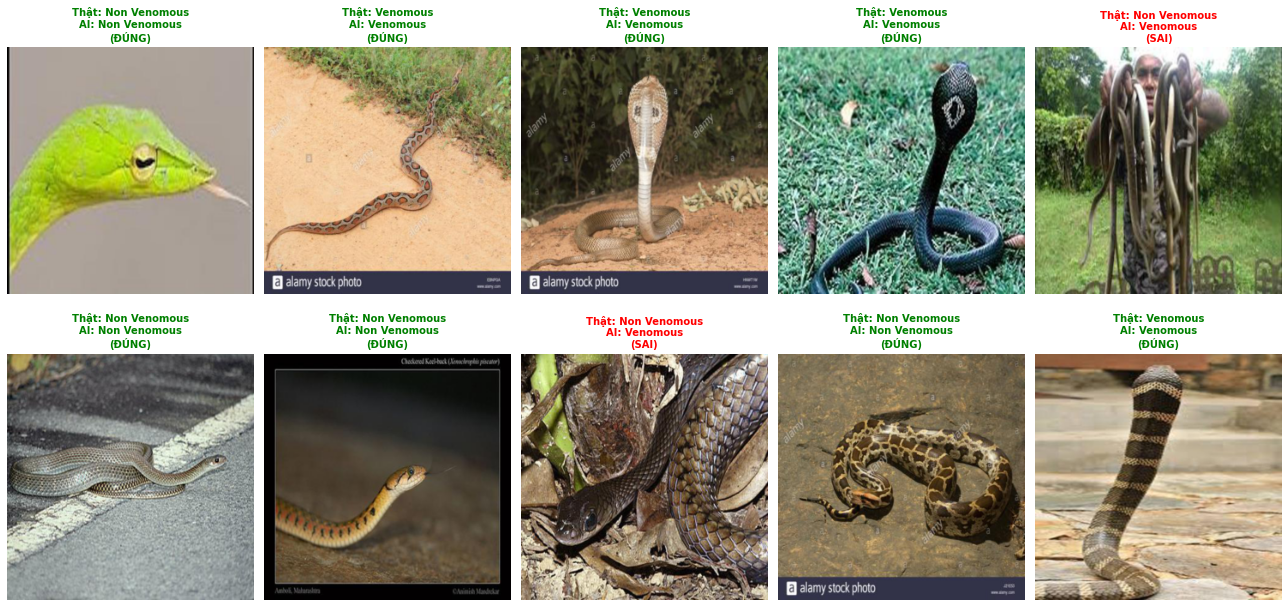

In [38]:
import random
import matplotlib.pyplot as plt
import torch

classes = dataset.classes 

fig, axes = plt.subplots(2, 5, figsize=(18, 9))
axes = axes.flatten()

model.eval()

with torch.no_grad(): 
    for i in range(10):
        random_idx = random.randint(0, len(val_ds) - 1)
        img_display, actual_label_idx = val_ds[random_idx] 
        img_predict, _ = val_set[random_idx] 
        xb = img_predict.unsqueeze(0).to(device)
        outputs = model(xb)
        _, preds = torch.max(outputs, dim=1)
        predicted_label_idx = preds[0].item()
        actual_name = classes[actual_label_idx]
        predicted_name = classes[predicted_label_idx]
        
# Vẽ hình ảnh lên lưới
        ax = axes[i]
        ax.imshow(img_display.permute(1, 2, 0))
        ax.axis('off')
        
#Kết quả
        is_correct = (actual_name == predicted_name)
        color = 'green' if is_correct else 'red'
        status = "ĐÚNG" if is_correct else "SAI"
            
        title = f"Thật: {actual_name}\nAI: {predicted_name}\n({status})"
        ax.set_title(title, color=color, fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

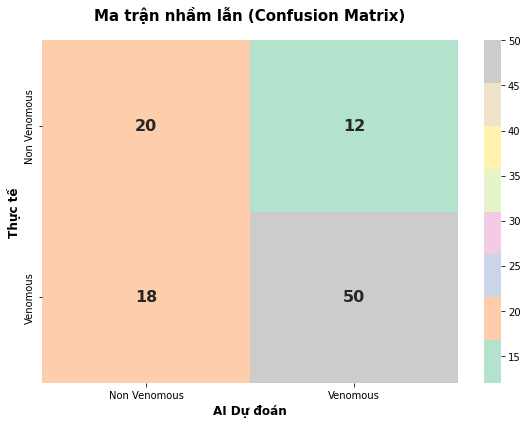


BÁO CÁO CHI TIẾT:
              precision    recall  f1-score   support

Non Venomous       0.53      0.62      0.57        32
    Venomous       0.81      0.74      0.77        68

    accuracy                           0.70       100
   macro avg       0.67      0.68      0.67       100
weighted avg       0.72      0.70      0.71       100



In [39]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import torch
import matplotlib.pyplot as plt
import numpy as np

model.eval()

y_true = []
y_hat = []  

# Chạy dữ liệu qua val_loader
with torch.no_grad():
    for images, labels in val_loader: 
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        
        y_true.extend(labels.cpu().numpy())
        y_hat.extend(predicted.cpu().numpy())

# Ma trận nhầm lẫn bằng sklearn
cm = confusion_matrix(y_true, y_hat)

# Lấy tên các loại rắn từ dataset gốc
class_names = dataset.classes

#Trực quan hoá bằng heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Pastel2', 
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={"size": 16, "weight": "bold"})

plt.title('Ma trận nhầm lẫn (Confusion Matrix)', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('AI Dự đoán', fontsize=12, fontweight='bold')
plt.ylabel('Thực tế', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


from sklearn.metrics import classification_report
print("\nBÁO CÁO CHI TIẾT:")
print(classification_report(y_true, y_hat, target_names=class_names))

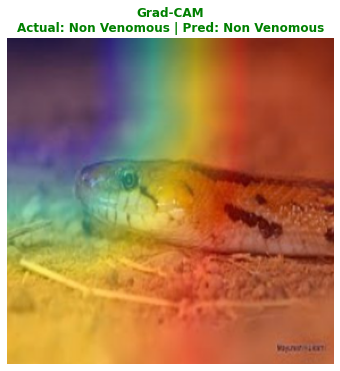

In [40]:
import cv2
import numpy as np

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self.target_layer.register_forward_hook(self.save_activations)
        self.target_layer.register_full_backward_hook(self.save_gradients)

    def save_activations(self, module, input, output):
        self.activations = output.detach()

    def save_gradients(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_image, class_idx=None):
        self.model.eval()
        output = self.model(input_image)
        if class_idx is None: class_idx = torch.argmax(output, dim=1).item()
        self.model.zero_grad()
        output[0, class_idx].backward()
        weights = torch.mean(self.gradients, dim=[2, 3])
        heatmap = torch.sum(weights[0, :, None, None] * self.activations[0], dim=0)
        heatmap = torch.maximum(heatmap, torch.tensor(0.0))
        heatmap /= (torch.max(heatmap) + 1e-10)
        return heatmap.cpu().numpy(), class_idx

def visualize_cam(img_tensor, heatmap, actual, pred, classes):
    mean, std = np.array([0.4914, 0.4822, 0.4465]), np.array([0.2023, 0.1994, 0.2010])
    img = img_tensor.permute(1, 2, 0).cpu().numpy()
    img = np.clip(std * img + mean, 0, 1)
    img = np.uint8(255 * img)
    
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    result = cv2.addWeighted(img, 0.6, heatmap, 0.4, 0)

    plt.figure(figsize=(8, 6))
    plt.imshow(result)
    plt.axis('off')
    color = 'green' if actual == pred else 'red'
    plt.title(f"Grad-CAM\nActual: {classes[actual]} | Pred: {classes[pred]}", color=color, fontweight='bold')
    plt.show()

# Thực thi
target_layer = model.res2[1][0] # Lớp Conv cuối cùng
cam = GradCAM(model, target_layer)

idx = random.randint(0, len(val_set)-1)
img_p, label = val_set[idx]
input_img = img_p.unsqueeze(0).to(device)

heatmap, pred_idx = cam.generate(input_img)
visualize_cam(img_p, heatmap, label, pred_idx, dataset.classes)

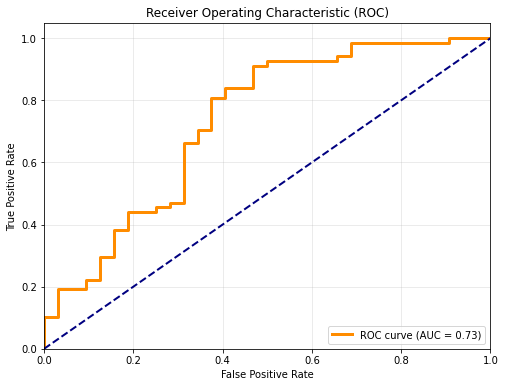

Điểm AUC: 0.7321


In [41]:
from sklearn.metrics import roc_curve, auc
import torch.nn.functional as F

# 1. Thu thập xác suất dự đoán và nhãn thực tế
model.eval()
y_true = []
y_scores = []

with torch.no_grad():
    for images, labels in val_loader:
        outputs = model(images)
        # Lấy xác suất của lớp 'Venomous' (index 1)
        probs = F.softmax(outputs, dim=1)[:, 1]
        
        y_true.extend(labels.cpu().numpy())
        y_scores.extend(probs.cpu().numpy())

# 2. Tính toán ROC và AUC
fpr, tpr, _ = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

# 3. Vẽ biểu đồ
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=3, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"Điểm AUC: {roc_auc:.4f}")

The graph here shows that the loss is getting stabled but the accuracy of the model is varying a bit. A reason of that could be less images than a usual dataset has or maybe some wrong model choice.  

The model is performing good with 75% val. accuracy. You can use this notebook for how to use this dataset using pytorch.

Thank you for visiting this notebook. Hope you have liked my efforts.

If you liked this nb, Do Upvote.